In [ ]:
import re
import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load Data**

Three csv dataset: train, test, and valid

In [ ]:
# Load train, valid, and test files into DataFrame
train_df = pd.read_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/RojakSentimentTrain.csv', header=None, names=["text", "label"])
valid_df = pd.read_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/RojakSentimentValid.csv', header=None, names=["text", "label"])
test_df = pd.read_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/RojakSentimentTest.csv', header=None, names=["text", "label"])

# Display basic information
print("Train Dataset:")
print(train_df.head())
print("\nValidation Dataset:")
print(valid_df.head())
print("\nTest Dataset:")
print(test_df.head())


Train Dataset:
                                                text  label
0                 Sadly SAPURA can touch 20sen..:)..     -1
1                             macam mau crash kali..     -1
2  Tun you do your best olwdy..this is malaysua f...      1
3  what??????? you also so lazy to do research on...     -1
4  1/3 of morning volume from IDSS....Set block b...     -1

Validation Dataset:
                                                text  label
0            Q4 QR must be bad or not good as Q3 QR.     -1
1  it's a trap, i had tried 1000lot, it was eaten...     -1
2  Ya fata, very obviously Armada operator is sti...     -1
3                                  ARMADA semput..:)     -1
4  TP for Jaks at 3.00? That is what promoters cr...     -1

Test Dataset:
                                                text  label
0                  I sold almost 2mil shares already     -1
1  (TO PREPARED PAY PENALTY OF 50 MILION TO STAR)...     -1
2  The ugly game just begin . Pnb boss in the boa

**Data Exploration and Visualization**


In [ ]:
print("Train Label Distribution:")
print(train_df['label'].value_counts())

print("\nValidation Label Distribution:")
print(valid_df['label'].value_counts())

print("\nTest Label Distribution:")
print(test_df['label'].value_counts())


Train Label Distribution:
label
-1    959
 1    831
Name: count, dtype: int64

Validation Label Distribution:
label
-1    112
 1     90
Name: count, dtype: int64

Test Label Distribution:
label
-1    139
 1    135
Name: count, dtype: int64


Train shape: (1790, 2)
Validation shape: (202, 2)
Test shape: (274, 2)


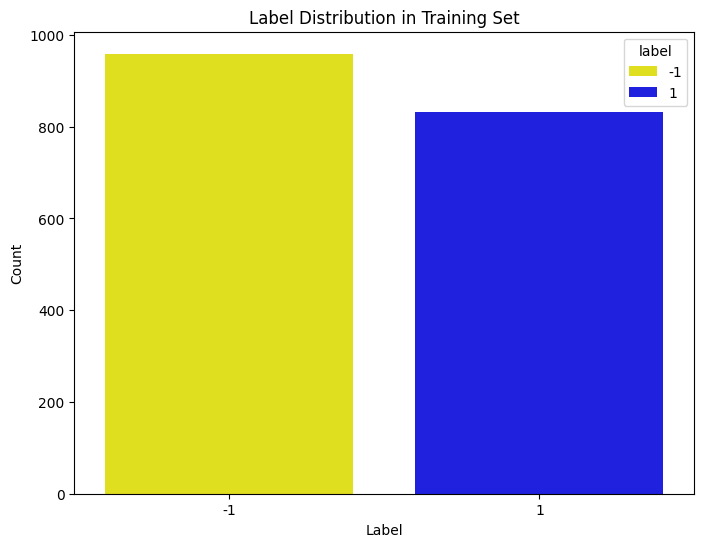

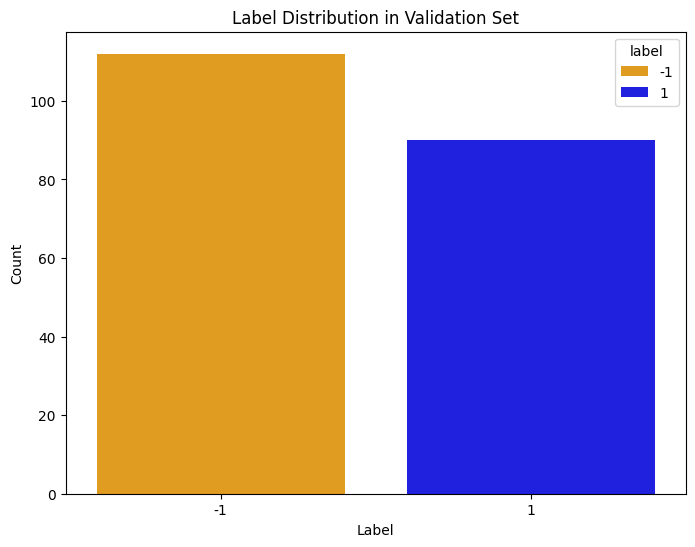

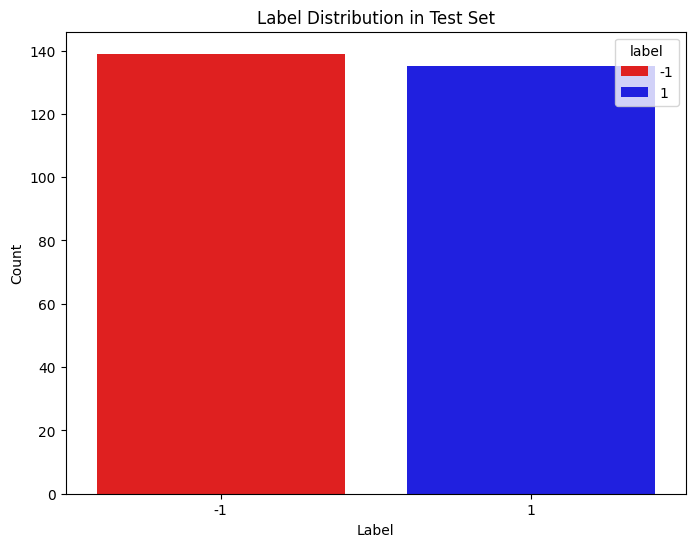

In [ ]:
# Check dataset shapes
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {valid_df.shape}")
print(f"Test shape: {test_df.shape}")

# count plot for 1 --> positive ; -1 --> negative
# Label Distribution in Training Set
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=train_df, hue='label',palette={1:'blue',-1:'yellow'})
plt.title('Label Distribution in Training Set')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Label Distribution in Validation Set
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=valid_df, hue='label',palette={1:'blue',-1:'orange'})
plt.title('Label Distribution in Validation Set')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Label Distribution in Test Set
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=test_df, hue='label',palette={1:'blue',-1:'red'})
plt.title('Label Distribution in Test Set')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

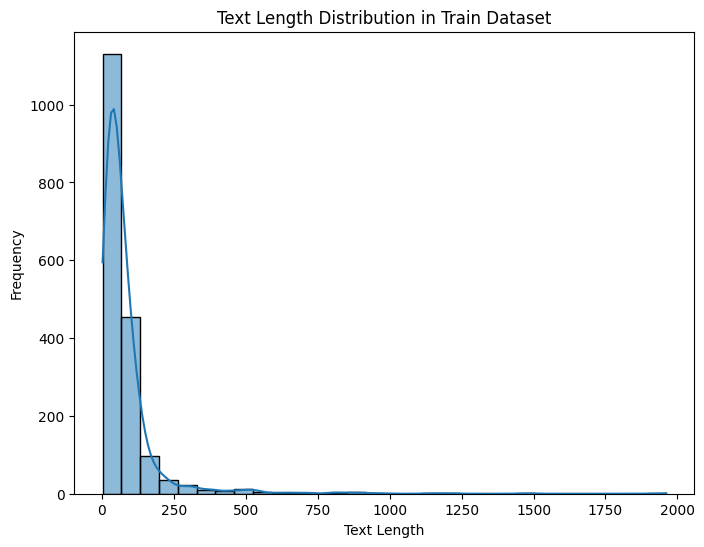

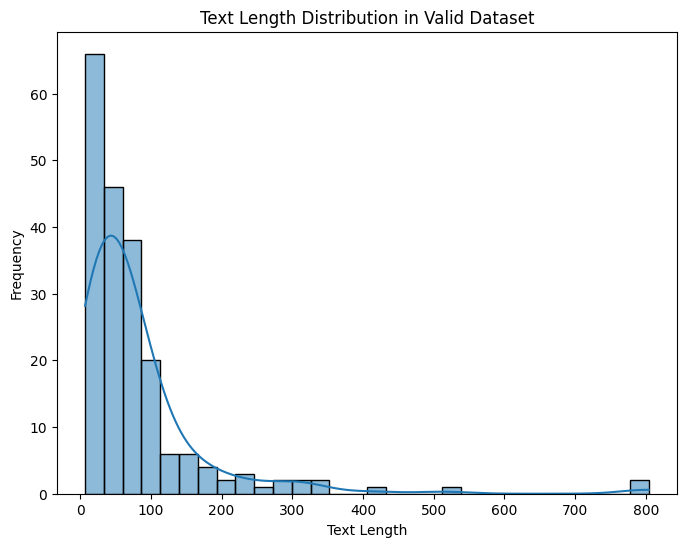

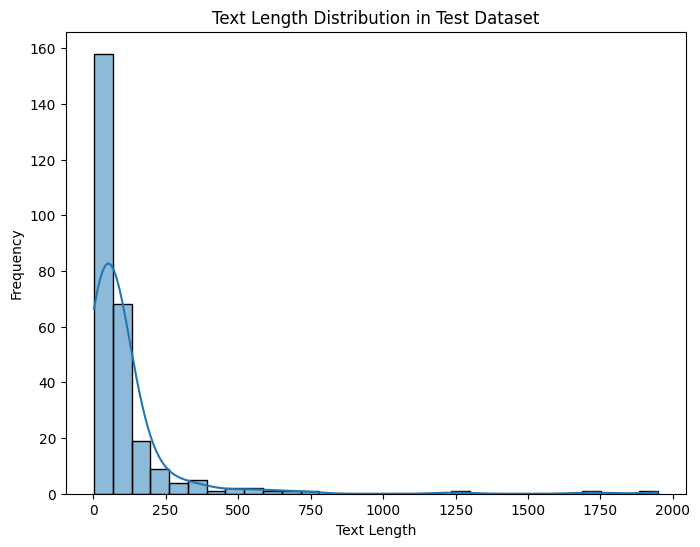

In [ ]:
train_df['text_length'] = train_df['text'].apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(train_df['text_length'], kde=True, bins=30)
plt.title('Text Length Distribution in Train Dataset')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

valid_df['text_length'] = valid_df['text'].apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(valid_df['text_length'], kde=True, bins=30)
plt.title('Text Length Distribution in Valid Dataset')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

test_df['text_length'] = test_df['text'].apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(test_df['text_length'], kde=True, bins=30)
plt.title('Text Length Distribution in Test Dataset')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Check for missing values in Train, Validation, and Test datasets
print("Missing values in Train Dataset:")
print(train_df.isnull().sum())

print("\nMissing values in Validation Dataset:")
print(valid_df.isnull().sum())

print("\nMissing values in Test Dataset:")
print(test_df.isnull().sum())


Missing values in Train Dataset:
text           0
label          0
text_length    0
dtype: int64

Missing values in Validation Dataset:
text           0
label          0
text_length    0
dtype: int64

Missing values in Test Dataset:
text           0
label          0
text_length    0
dtype: int64


In [ ]:
from collections import Counter

def get_frequent_words(texts, n=10):
    tokens = ' '.join(texts).split()
    return Counter(tokens).most_common(n)

print("Most common words in Train Dataset:")
print(get_frequent_words(train_df['text'], n=10))


Most common words in Train Dataset:
[('.', 790), ('to', 492), ('the', 481), ('is', 439), ('and', 379), (',', 313), ('a', 288), ('I', 278), ('of', 227), ('yang', 218)]


<ipython-input-9-2a6061ba8c16>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_counts, y=positive_words, palette='Blues_r')


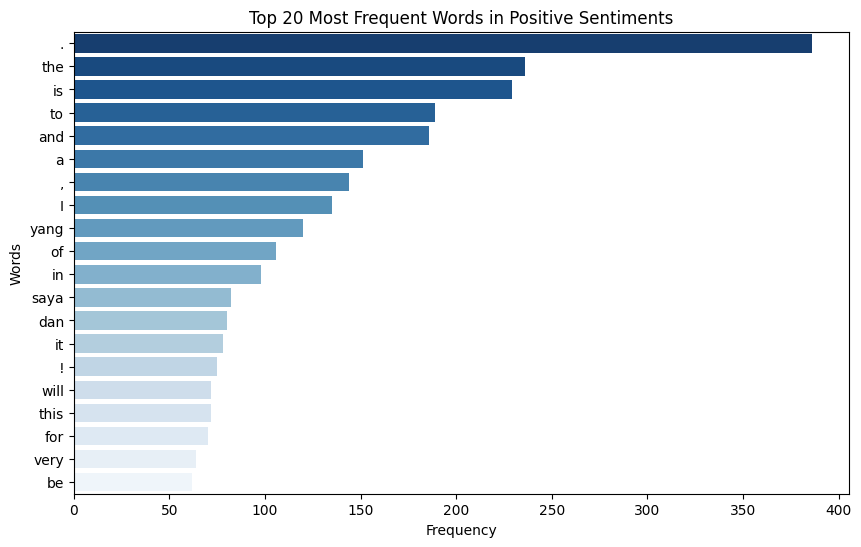

<ipython-input-9-2a6061ba8c16>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_counts, y=negative_words, palette='Reds_r')


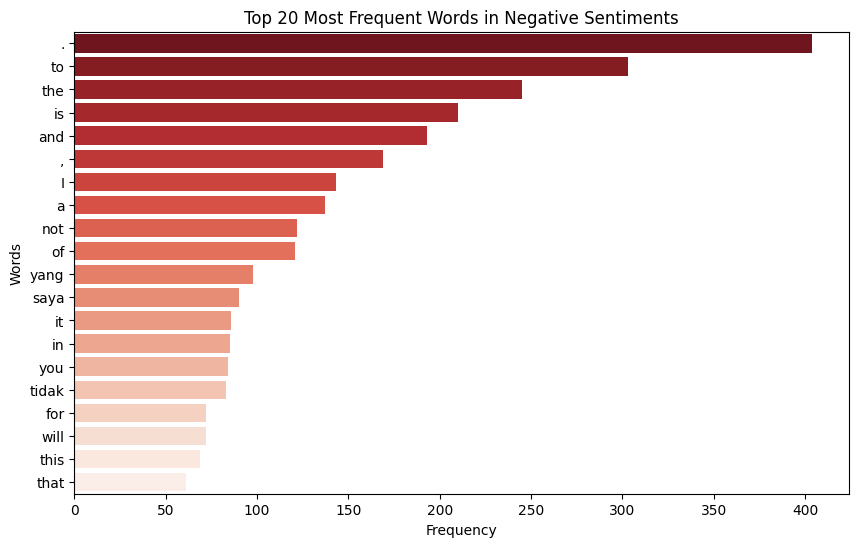

In [ ]:
from collections import Counter

# Function to get frequent words
def get_frequent_words(texts, n=10):
    tokens = ' '.join(texts).split()
    return Counter(tokens).most_common(n)

# Separate positive and negative sentiments
positive_texts = train_df[train_df['label'] == 1]['text']
negative_texts = train_df[train_df['label'] == -1]['text']

# Get most frequent words for positive and negative sentiments
positive_frequent_words = get_frequent_words(positive_texts, n=20)
negative_frequent_words = get_frequent_words(negative_texts, n=20)

# Unpack words and counts
positive_words, positive_counts = zip(*positive_frequent_words)
negative_words, negative_counts = zip(*negative_frequent_words)

# Plot for Positive Sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x=positive_counts, y=positive_words, palette='Blues_r')
plt.title('Top 20 Most Frequent Words in Positive Sentiments')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

# Plot for Negative Sentiment
plt.figure(figsize=(10, 6))
sns.barplot(x=negative_counts, y=negative_words, palette='Reds_r')
plt.title('Top 20 Most Frequent Words in Negative Sentiments')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()


**Data Preprocessing**

Remove URLs, hashtags, emojis, non-ASCII characters, punctuation, numbers, lowercasing

In [ ]:
def clean_text(text):
    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove emojis and non-ASCII characters
    text = re.sub(r'[^\x00-\x7f]', r'', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Convert to lowercase
    text = text.lower()
    return text

# Apply cleaning
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
valid_df['cleaned_text'] = valid_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['text'].apply(clean_text)


Handling Out-Of-Vocabulary Words

In [ ]:
import ast

# Read OOV dictionary from file
oov_dict = {}
with open('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/NLP OOV.txt', 'r') as file:
    for line_num, line in enumerate(file, start=1):
        try:
            # Parse line as dictionary and merge with oov_dict
            line_dict = ast.literal_eval(f"{{{line.strip()}}}")
            oov_dict.update(line_dict)
        except (ValueError, SyntaxError) as e:
            print(f"Skipping invalid line {line_num}: {line.strip()} | Error: {e}")

# Normalize OOV dictionary to lowercase
oov_dict = {k.lower(): v for k, v in oov_dict.items()}

# Function to replace slang with full forms
def replace_slang(text, oov_dict):
    # Split text into tokens, keeping punctuation
    tokens = re.findall(r'\b\w+\b|\S', text)
    # Replace slang terms
    replaced_tokens = [oov_dict.get(token.lower(), token) for token in tokens]
    return ' '.join(replaced_tokens)

# Apply replacement to each DataFrame
for df in [train_df, valid_df, test_df]:
    if 'text' in df.columns:
        df['text'] = df['text'].apply(lambda x: replace_slang(x, oov_dict))


Skipping invalid line 1: ﻿";)": "winking face", | Error: invalid non-printable character U+FEFF (<unknown>, line 1)
Skipping invalid line 320: "nvm": nevermind", | Error: unterminated string literal (detected at line 1) (<unknown>, line 1)
Skipping invalid line 345: "rsvp": please reply", | Error: unterminated string literal (detected at line 1) (<unknown>, line 1)


Tokenization

In [ ]:
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

train_df['tokens'] = train_df['cleaned_text'].apply(word_tokenize)
valid_df['tokens'] = valid_df['cleaned_text'].apply(word_tokenize)
test_df['tokens'] = test_df['cleaned_text'].apply(word_tokenize)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# Display some examples of tokenized text
def display_tokenized_examples(df, num_examples=5):
    for i in range(num_examples):
        print(f"Original Text {i+1}: {df['cleaned_text'].iloc[i]}")
        print(f"Tokenized Text {i+1}: {df['tokens'].iloc[i]}")
        print("-" * 50)

print("Tokenized Results from Training Dataset:")
display_tokenized_examples(train_df)

print("\nTokenized Results from Validation Dataset:")
display_tokenized_examples(valid_df)

print("\nTokenized Results from Test Dataset:")
display_tokenized_examples(test_df)


Tokenized Results from Training Dataset:
Original Text 1: sadly sapura can touch sen
Tokenized Text 1: ['sadly', 'sapura', 'can', 'touch', 'sen']
--------------------------------------------------
Original Text 2: macam mau crash kali
Tokenized Text 2: ['macam', 'mau', 'crash', 'kali']
--------------------------------------------------
Original Text 3: tun you do your best olwdythis is malaysua fate
Tokenized Text 3: ['tun', 'you', 'do', 'your', 'best', 'olwdythis', 'is', 'malaysua', 'fate']
--------------------------------------------------
Original Text 4: what you also so lazy to do research on jaks forum how we take your advice    tut tut just wonder hurmm
Tokenized Text 4: ['what', 'you', 'also', 'so', 'lazy', 'to', 'do', 'research', 'on', 'jaks', 'forum', 'how', 'we', 'take', 'your', 'advice', 'tut', 'tut', 'just', 'wonder', 'hurmm']
--------------------------------------------------
Original Text 5:  of morning volume from idssset block big big lalater kena wash
Tokenized Text 5

Stopword removal

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Load stopwords for English, Malay, and Chinese
english_stopwords = set(stopwords.words('english'))

with open('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/malaysian.txt', 'r', encoding='utf-8') as f:
    malay_stopwords = set(f.read().splitlines())

with open('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/cn_stopwords.txt', 'r', encoding='utf-8') as f:
    chinese_stopwords = set(f.read().splitlines())

In [ ]:
# Combine all stopwords into a single set
all_stopwords = english_stopwords.union(malay_stopwords, chinese_stopwords)

In [ ]:
def remove_stopwords(tokens, stopword_set):
    return [word for word in tokens if word not in stopword_set]

# Apply stopword removal to the tokenized text
train_df['filtered_tokens'] = train_df['tokens'].apply(lambda x: remove_stopwords(x, all_stopwords))
valid_df['filtered_tokens'] = valid_df['tokens'].apply(lambda x: remove_stopwords(x, all_stopwords))
test_df['filtered_tokens'] = test_df['tokens'].apply(lambda x: remove_stopwords(x, all_stopwords))

# Display results for verification
train_df[['tokens', 'filtered_tokens']].head()


,tokens,filtered_tokens
0,"[sadly, sapura, can, touch, sen]","[sadly, sapura, touch, sen]"
1,"[macam, mau, crash, kali]","[macam, mau, crash, kali]"
2,"[tun, you, do, your, best, olwdythis, is, mala...","[tun, best, olwdythis, malaysua, fate]"
3,"[what, you, also, so, lazy, to, do, research, ...","[also, lazy, research, jaks, forum, take, advi..."
4,"[of, morning, volume, from, idssset, block, bi...","[morning, volume, idssset, block, big, big, la..."


Lemmatization and POS Tagging

In [ ]:
pip install langdetect

In [ ]:
pip install Sastrawi

In [ ]:
import langdetect
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import WordNetLemmatizer
from langdetect import detect
import jieba
from nltk.corpus import wordnet
from nltk import pos_tag

# Initialize Sastrawi stemmer for Malay
factory = StemmerFactory()
sastrawi_stemmer = factory.create_stemmer()

# Initialize WordNet lemmatizer for English
wordnet_lemmatizer = WordNetLemmatizer()

# Function to get WordNet POS from NLTK POS tagging
def get_wordnet_pos(word):
    # Get POS tag from NLTK and map it to WordNet POS tags
    tag = pos_tag([word])[0][1][0].upper()
    tag_dict = {
        'J': wordnet.ADJ,  # Adjective
        'N': wordnet.NOUN,  # Noun
        'V': wordnet.VERB,  # Verb
        'R': wordnet.ADV    # Adverb
    }
    return tag_dict.get(tag, wordnet.NOUN)  # Default to noun if no match

# Language-specific lemmatization function
def lemmatize_token(token):
    try:
        lang = detect(token)
        if lang == 'en':
            pos = get_wordnet_pos(token)  # Get the correct POS
            return wordnet_lemmatizer.lemmatize(token, pos=pos)  # Lemmatize with POS
        elif lang == 'ms':
            return sastrawi_stemmer.stem(token)
        elif lang == 'zh':
            segmented = jieba.lcut(token)
            return ' '.join(segmented)  # Jieba normalization
        else:
            return token

    except Exception as e:
        return token

# Apply lemmatization to a list of tokens
def lemmatize_tokens(tokens):
    return [lemmatize_token(token) for token in tokens]

# Apply lemmatization to the datasets
train_df['lemmatized_tokens'] = train_df['filtered_tokens'].apply(lemmatize_tokens)
valid_df['lemmatized_tokens'] = valid_df['filtered_tokens'].apply(lemmatize_tokens)
test_df['lemmatized_tokens'] = test_df['filtered_tokens'].apply(lemmatize_tokens)

# Display example results
print("Examples of Lemmatized Tokens:")
print(test_df[['filtered_tokens', 'lemmatized_tokens']].head())


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Examples of Lemmatized Tokens:
                                     filtered_tokens  \
0               [sold, almost, mil, shares, already]   
1  [prepared, pay, penalty, milion, star, totally...   
2              [ugly, game, begin, pnb, boss, board]   
3  [pang, u, dont, say, peopleu, last, also, talk...   
4  [sorchai, missed, point, dares, call, people, ...   

                                   lemmatized_tokens  
0               [sold, almost, mil, shares, already]  
1  [prepared, pay, penalty, milion, star, totally...  
2               [ugly, game, begin, pnb, bos, board]  
3  [pang, u, dont, say, peopleu, last, also, talk...  
4  [sorchai, missed, point, dares, call, people, ...  


**Organize and Save data after preprocessing**

In [ ]:
# Retain necessary columns for modeling
train_df_clean = train_df[['lemmatized_tokens', 'label']].copy()
valid_df_clean = valid_df[['lemmatized_tokens', 'label']].copy()
test_df_clean = test_df[['lemmatized_tokens', 'label']].copy()

# Convert tokens back to text (if required for your model)
train_df_clean['processed_text'] = train_df_clean['lemmatized_tokens'].apply(lambda x: ' '.join(x))
valid_df_clean['processed_text'] = valid_df_clean['lemmatized_tokens'].apply(lambda x: ' '.join(x))
test_df_clean['processed_text'] = test_df_clean['lemmatized_tokens'].apply(lambda x: ' '.join(x))

# Drop the token columns if only processed_text is needed
train_df_clean = train_df_clean[['processed_text', 'label']]
valid_df_clean = valid_df_clean[['processed_text', 'label']]
test_df_clean = test_df_clean[['processed_text', 'label']]


In [ ]:
# Remove rows with empty processed_text
train_df_clean = train_df_clean[train_df_clean['processed_text'].str.strip() != '']
valid_df_clean = valid_df_clean[valid_df_clean['processed_text'].str.strip() != '']
test_df_clean = test_df_clean[test_df_clean['processed_text'].str.strip() != '']

In [ ]:
train_df_clean.to_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/train_preprocessed.csv', index=False)
valid_df_clean.to_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/valid_preprocessed.csv', index=False)
test_df_clean.to_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/test_preprocessed.csv', index=False)




---


**HLP Dataset Preprocessing**

In [ ]:
import os

# Load the HLP datasets
hlp_train_df = pd.read_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/HLPTrain.csv', header=None, names=["text", "label"], encoding='ISO-8859-1')
hlp_valid_df = pd.read_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/HLPValid.csv', header=None, names=["text", "label"], encoding='ISO-8859-1')
hlp_test_df = pd.read_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/HLPTest.csv', header=None, names=["text", "label"], encoding='ISO-8859-1')

print("HLP Train Dataset:")
print(hlp_train_df.head())
print("\nHLP Validation Dataset:")
print(hlp_valid_df.head())
print("\nHLP Test Dataset:")
print(hlp_test_df.head())

# Step 1: Clean the HLP Text
hlp_train_df['cleaned_text'] = hlp_train_df['text'].apply(clean_text)
hlp_valid_df['cleaned_text'] = hlp_valid_df['text'].apply(clean_text)
hlp_test_df['cleaned_text'] = hlp_test_df['text'].apply(clean_text)

# Step 2: Replace Slang Words in HLP Text
hlp_train_df['text'] = hlp_train_df['text'].apply(lambda x: replace_slang(x, oov_dict))
hlp_valid_df['text'] = hlp_valid_df['text'].apply(lambda x: replace_slang(x, oov_dict))
hlp_test_df['text'] = hlp_test_df['text'].apply(lambda x: replace_slang(x, oov_dict))

# Step 3: Tokenize the HLP Text
hlp_train_df['tokens'] = hlp_train_df['cleaned_text'].apply(word_tokenize)
hlp_valid_df['tokens'] = hlp_valid_df['cleaned_text'].apply(word_tokenize)
hlp_test_df['tokens'] = hlp_test_df['cleaned_text'].apply(word_tokenize)

# Step 4: Remove Stopwords from HLP Text
hlp_train_df['filtered_tokens'] = hlp_train_df['tokens'].apply(lambda x: remove_stopwords(x, all_stopwords))
hlp_valid_df['filtered_tokens'] = hlp_valid_df['tokens'].apply(lambda x: remove_stopwords(x, all_stopwords))
hlp_test_df['filtered_tokens'] = hlp_test_df['tokens'].apply(lambda x: remove_stopwords(x, all_stopwords))

# Step 5: Lemmatize the HLP Text
hlp_train_df['lemmatized_tokens'] = hlp_train_df['filtered_tokens'].apply(lemmatize_tokens)
hlp_valid_df['lemmatized_tokens'] = hlp_valid_df['filtered_tokens'].apply(lemmatize_tokens)
hlp_test_df['lemmatized_tokens'] = hlp_test_df['filtered_tokens'].apply(lemmatize_tokens)

# Step 6: Prepare Final Cleaned HLP DataFrames
hlp_train_clean = hlp_train_df[['lemmatized_tokens', 'label']].copy()
hlp_valid_clean = hlp_valid_df[['lemmatized_tokens', 'label']].copy()
hlp_test_clean = hlp_test_df[['lemmatized_tokens', 'label']].copy()

# Convert tokens back to text
hlp_train_clean['processed_text'] = hlp_train_clean['lemmatized_tokens'].apply(lambda x: ' '.join(x))
hlp_valid_clean['processed_text'] = hlp_valid_clean['lemmatized_tokens'].apply(lambda x: ' '.join(x))
hlp_test_clean['processed_text'] = hlp_test_clean['lemmatized_tokens'].apply(lambda x: ' '.join(x))

# Drop rows with empty text
hlp_train_clean = hlp_train_clean[hlp_train_clean['processed_text'].str.strip() != '']
hlp_valid_clean = hlp_valid_clean[hlp_valid_clean['processed_text'].str.strip() != '']
hlp_test_clean = hlp_test_clean[hlp_test_clean['processed_text'].str.strip() != '']

# Save the Cleaned HLP Datasets for Later Use
hlp_train_clean.to_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/hlp_train_preprocessed.csv', index=False)
hlp_valid_clean.to_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/hlp_valid_preprocessed.csv', index=False)
hlp_test_clean.to_csv('/content/drive/MyDrive/RojakLanguageSentimentAnalysis/hlp_test_preprocessed.csv', index=False)

print("\nHLP Datasets have been preprocessed and saved for later use.")


HLP Train Dataset:
                                                text  label
0                 Sadly SAPURA can touch 20sen..:)..     -1
1                             macam mau crash kali..     -1
2  Tun you do your best olwdy..this is malaysua f...      1
3  what??????? you also so lazy to do research on...     -1
4  1/3 of morning volume from IDSS....Set block b...     -1

HLP Validation Dataset:
                                                text  label
0            Q4 QR must be bad or not good as Q3 QR.     -1
1  it's a trap, i had tried 1000lot, it was eaten...     -1
2  Ya fata, very obviously Armada operator is sti...     -1
3                                  ARMADA semput..:)     -1
4  TP for Jaks at 3.00? That is what promoters cr...     -1

HLP Test Dataset:
                                                text  label
0                  I sold almost 2mil shares already     -1
1  (TO PREPARED PAY PENALTY OF 50 MILION TO STAR)...     -1
2  The ugly game just begin . Pnb bos